# <center>Noise in the wild: a pulsar safari</center>

### <center><span style="font-family:Comic Sans MS; color:blue">Prepared by Valentina Di Marco </span></center>

---

## A field guide to PTA noise

To detect gravitational waves with a pulsar timing array, we need to understand every other process that can shift a pulse arrival time. Out in the wild of PTA data, these processes form a small ecosystem, and our first job is to learn to recognise each one.

The variations in pulse arrival times come from two kinds of sources:

- **Deterministic** effects, captured in the pulsar ephemeris. These include the nonlinear change in the pulsar-Earth distance, relativistic propagation effects within the Solar System, and, if the pulsar has a companion, the orbital motion of the binary.
- **Stochastic** effects, which are the focus of this tutorial. These are the noise processes we have to model statistically rather than predict exactly.

Stochastic contributions are categorised by their temporal correlation:

1. **White noise**: temporally uncorrelated.
2. **Red noise**: temporally correlated.

**White noise** is the background buzz of the savanna. Its main contributors are *radiometer noise* (thermal noise from the radio telescope) and *pulse jitter* (intrinsic shape variations from one pulse to the next).

**Red noise** is the slower, lumbering kind. It is subdivided into two flavours:

- **Achromatic red noise** does not depend on the observing radio frequency. The most common source is *timing noise* (also called *spin noise*), and it is due to irregularities in the neutron star's rotation.
- **Chromatic red noise** does depend on radio frequency. The dominant contributor is *dispersion measure (DM) variations*, caused by changes in the ionised plasma column density along the pulsar-Earth line of sight. The *solar wind* introduces additional, more localised DM variations as the line of sight passes close to the Sun. Other chromatic processes have also been identified, including *band-dependent* noise (tied to specific radio bands) and *system-dependent* noise (tied to a telescope backend). Their origins are still uncertain and are usually attributed to propagation effects in the interstellar medium or to instrumental systematics.

A real PTA dataset is a tangle of all of these at once. The art of noise modelling is separating them, because what looks like a gravitational wave signal in one pulsar might just be timing noise in disguise.

For a deeper dive into PTA noise modelling, see [Goncharov et al. 2021](https://academic.oup.com/mnras/article/502/1/478/5957533).

## Modelling the residuals

Each pulse arrival time (TOA) in our dataset gives us a *timing residual*: the difference between the observed arrival time and the time predicted by our deterministic timing model. If our timing model were perfect and the universe were quiet, every residual would be zero. In practice, they are not, and the structure of the non-zero residuals is exactly where the noise (and any gravitational wave signal) lives.

A vector of $N_{\rm TOA}$ residuals can be modelled as the sum of several deterministic and stochastic contributions:

$$\delta t = M\epsilon + Fa + F_{\rm DM}\,a_{\rm DM} + Uj + n.$$

Each term plays a different role:

- $M\epsilon$ is the linearised correction to the deterministic timing model. $M$ is the design matrix of partial derivatives of the model with respect to its parameters, and $\epsilon$ is a small vector of offsets to those parameters that we marginalise over during inference.
- $Fa$ models *achromatic red noise* (timing noise) via a Fourier decomposition. $F$ is the Fourier design matrix whose columns are alternating sines and cosines, $F_{i,2k} = \cos(2\pi f_k t_i)$ and $F_{i,2k+1} = \sin(2\pi f_k t_i)$, evaluated at the observation times $t_i$. The coefficient vector $a$ contains the amplitudes of each Fourier mode.
- $F_{\rm DM}\,a_{\rm DM}$ models *chromatic red noise* due to dispersion measure variations, using the same Fourier basis but scaled by a frequency-dependent factor (see below). Other chromatic processes are added analogously.
- $Uj$ models *jitter-like* noise: uncorrelated between observing epochs but fully correlated between TOAs taken in the same epoch (e.g. simultaneous multi-frequency observations). $U$ is the *exploder matrix*, a binary $N_{\rm TOA} \times N_{\rm epoch}$ matrix whose entry $U_{ij}$ is 1 if TOA $i$ belongs to epoch $j$ and 0 otherwise. The vector $j$ holds one jitter realisation per epoch.
- $n$ is the leftover Gaussian *white noise*: time-uncorrelated, frequency-independent scatter.

### White noise (EFAC and EQUAD)

The white noise vector $n$ is modelled as a zero-mean Gaussian,

$$p(n) = \frac{\exp\!\left(-\tfrac{1}{2}\, n^{T} N^{-1} n\right)}{\sqrt{\det(2\pi N)}},$$

with a diagonal covariance matrix. For each TOA $i$ with uncertainty $\sigma_i$,

$$N_{ii} = E^{2}\left(\sigma_{i}^{2} + Q^{2}\right),$$

where $E$ is the **EFAC** parameter (a dimensionless multiplicative scaling of the reported uncertainties) and $Q$ is the **EQUAD** parameter (an extra noise added in quadrature, in seconds). This is the convention used by `libstempo` and `tempo2`. Be aware that the alternative *TempoNest* convention places EFAC only on the radiometer term, $N_{ii} = E^{2}\sigma_{i}^{2} + Q^{2}$. Always check which convention your software uses!

### ECORR (jitter-like noise)

The jitter vector $j$ has one entry per observing epoch and is also Gaussian,

$$p(j) = \frac{\exp\!\left(-\tfrac{1}{2}\, j^{T} J^{-1} j\right)}{\sqrt{\det(2\pi J)}},\qquad J = c^{2}\, I_{N_{\rm epoch}},$$

where $c$ is the **ECORR** amplitude (in seconds) and $I_{N_{\rm epoch}}$ is the identity matrix over epochs. When projected onto the TOA basis via the exploder matrix $U$, this produces a block-diagonal covariance:

$$C_{\rm ECORR} = U J U^{T},$$

which is fully correlated within each observing epoch and zero between epochs. Different observing backends typically have different values of ECORR.


### Two approaches to ECORR

The formulation above treats ECORR via an explicit low-rank basis: a latent jitter vector $j$ is drawn from a Gaussian prior and projected onto the TOA basis by the exploder matrix $U$. There is a second, equivalent approach in which the jitter is absorbed directly into the white noise covariance matrix.

**Approach (a): explicit jitter basis.** This is the formulation given above. The jitter vector $j \sim \mathcal{N}(0, J)$ enters as a set of latent variables, one per epoch, and the white noise covariance $N$ remains purely diagonal (EFAC and EQUAD only). The full residual covariance is $C = N + UJU^T$, but rather than forming this $N_{\rm TOA} \times N_{\rm TOA}$ matrix explicitly, one exploits the Woodbury identity to invert it efficiently.

**Approach (b): ECORR absorbed into the white noise covariance.** You can marginalise over $j$ analytically. Writing the total noise as $\delta t = Uj + n$ with $j \sim \mathcal{N}(0,J)$ and $n \sim \mathcal{N}(0,N)$ independent, the standard Gaussian marginalisation identity gives

$$p(\delta t) = \int \mathcal{N}(Uj,\,N)\,\mathcal{N}(0,\,J)\,dj = \mathcal{N}(0,\,N + UJU^{T}).$$

The combined covariance $N + UJU^{T}$ is block-diagonal: diagonal entries carry the EFAC and EQUAD terms, and the within-epoch off-diagonal entries are filled by $c^{2}$ from the ECORR prior. Entries between different epochs are zero. No latent variables appear; the amplitude $c$ parametrises the off-diagonal structure directly.

The two approaches yield identical likelihoods. Approach (b) makes the noise structure geometrically transparent but requires inverting a block-diagonal $N_{\rm TOA} \times N_{\rm TOA}$ matrix. Approach (a) keeps $N$ small and diagonal, handling the epoch correlations analytically via the Woodbury identity,

$$(A + UCV)^{-1} = A^{-1} - A^{-1}U\bigl(C^{-1} + VA^{-1}U\bigr)^{-1}VA^{-1},$$

with $A = N$, $C = J$, $V = U^{T}$. Since $N^{-1}$ is diagonal and the matrix requiring explicit inversion is only $N_{\rm epoch} \times N_{\rm epoch}$, the computational cost drops from $O(N_{\rm TOA}^{3})$ to $O(N_{\rm TOA}\,N_{\rm epoch}^{2})$. In practice, jitter can be stacked alongside achromatic red noise into a single augmented basis $\tilde{F} = [F,\,U]$ with combined prior diagonal $\tilde{\varphi} = {\rm diag}(\varphi_{\rm red},\,\varphi_{j})$, so a single Woodbury step handles both simultaneously. This is the formulation used in [`libstempo`](https://github.com/vallis/libstempo), a Python wrapper around the [`tempo2`](https://bitbucket.org/psrsoft/tempo2) pulsar timing package, which makes simulating pulsars considerably easier and which we will use in this tutorial.


### Achromatic red noise (timing noise)

The Fourier coefficients $a$ of the achromatic red noise are also Gaussian-distributed,

$$p(a) = \frac{\exp\!\left(-\tfrac{1}{2}\, a^{T} \varphi^{-1} a\right)}{\sqrt{\det(2\pi \varphi)}},$$

with a diagonal prior covariance $\varphi$ whose entries follow a power law. For Fourier frequency $f_n = n/T$,

$$\varphi_{n} = \frac{1}{T}\, P(f_n) = \frac{A^{2}}{12\pi^{2}\, T}\, \left(\frac{f_n}{f_{\rm ref}}\right)^{-\gamma}\, f_{\rm ref}^{-3},$$

where $T$ is the total observation time, $P(f)$ is the power spectral density, $A$ is the (dimensionless) amplitude of the red noise, $\gamma$ is the spectral index, $f_{\rm ref} = 1\,{\rm yr}^{-1}$ is the reference frequency, and $f_n$ is the $n$th Fourier frequency. The $f_{\rm ref}^{-3}$ factor ensures $\varphi_n$ has units of $\rm s^{2}$.

A stochastic gravitational wave background is modelled by exactly the same power-law form, with characteristic values $\gamma_{\rm GWB} = 13/3$ and $A_{\rm GWB}$ of order $10^{-15}$ for the signal hinted at by current PTAs.

### Chromatic red noise (DM and friends)

Chromatic processes use the same Fourier basis as the achromatic red noise, but each row is scaled by a frequency-dependent factor:

$$(F_{\rm DM})_{ij} = \frac{F_{ij}}{K\, \nu_{i}^{\beta}},$$

where $\nu_i$ is the observing radio frequency of TOA $i$, $K = 2.41 \times 10^{-16}\,{\rm Hz}^{-2}\,{\rm cm}^{-3}\,{\rm pc}\,{\rm s}^{-1}$ is the dispersion constant, and $\beta$ is the *chromaticity index*. For dispersion measure variations, $\beta = 2$ exactly (cold-plasma dispersion). Other chromatic processes can have $\beta \neq 2$: scattering in the interstellar medium typically gives $\beta \approx 4$, and band- or system-dependent noise can have other values still. The prior on the Fourier coefficients $a_{\rm DM}$ is again a power law with its own amplitude and spectral index.

For a thorough treatment of the residual model, see Appendix C of [Lentati et al. 2015](https://iopscience.iop.org/article/10.1088/0004-637X/813/1/65).

A gravitational wave would also induce a common red noise signal in the residual which is modelled as a power law

---

## 1. Setting up camp

Before we head out on safari, we need to set up camp. In this section we will:

1. Import the Python packages we need.
2. Point to the pulsar data directory.
3. Inspect the `.par` and `.tim` files for our first pulsar.
4. Define a few helper functions for noise injection that `libstempo` doesn't provide out of the box.

In [ ]:
# Jupyter display settings
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

# Standard packages
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as sc
import math
import os

# Pulsar-timing packages
import libstempo as T
import libstempo.toasim as LT
import libstempo.plot as LP

ModuleNotFoundError: No module named 'libstempo'

We need data from a real pulsar: a **`.par`** file and a **`.tim`** file.

- The `.par` file contains the parameters of the deterministic timing model (position, spin frequency, dispersion measure, binary parameters, etc.).
- The `.tim` file is a plain text file with one row per TOA, listing the observation site, radio frequency, arrival time (in MJD), and uncertainty.

In [ ]:
datadir = 'data/array/'

Let's peek inside the `.tim` file. The second column is the radio frequency (MHz), the third is the time of arrival (MJD), and the fourth is the TOA uncertainty. Notice how high the precision is.We can have a look at the .tim file. The second column specifies the radio frequency in MHz and the third column shows the time of arrivals in MJD; notice the incredibly high precision. You can find all the flags in the [Tempo2 manual](https://www.jb.man.ac.uk/research/pulsar/Resources/tempo2_manual.pdf)

In [ ]:
with open(datadir + "J0437-4715.tim", "r") as file:
    for _ in range(10):  # Read first 10 lines
        print(file.readline().strip())

FORMAT 1
MODE 1
0 3100.00000000 50000.00000000001159250 0.04220 pks -or pks -sched sched_similar_regsamp -tobs 600 -pn 0
1 1400.00000000 49999.99999998494295284 0.05520 pks -or pks -sched sched_similar_regsamp -tobs 3100 -pn -1
2 600.00000000 50000.00000000631017372 0.14100 pks -or pks -sched sched_similar_regsamp -tobs 1400 -pn -5
3 3100.00000000 50025.00000000097955777 0.04220 pks -or pks -sched sched_similar_regsamp -tobs 600 -pn 375170084
4 1400.00000000 50024.99999998591317407 0.05520 pks -or pks -sched sched_similar_regsamp -tobs 3100 -pn 375170083
5 600.00000000 50025.00000000728416438 0.14100 pks -or pks -sched sched_similar_regsamp -tobs 1400 -pn 375170079
6 3100.00000000 50049.99999997562487408 0.04220 pks -or pks -sched sched_similar_regsamp -tobs 600 -pn 750336071
7 1400.00000000 50050.00000002719331960 0.05520 pks -or pks -sched sched_similar_regsamp -tobs 3100 -pn 750336071


And the `.par` file. For more on `.par` and `.tim` formats, see the [tempo2 manual](https://www.jb.man.ac.uk/research/pulsar/Resources/tempo2_manual.pdf).

In [ ]:
with open(datadir + "J0437-4715.par", "r") as file:
    content = file.read()
print(content)

PSRJ           J0437-4715
RAJ            04:37:15.8146878            
DECJ           -47:15:08.62242             
F0             173.68794618476152414     1  1.7332112666829205381e-14
F1             -1.7283528971776862244e-15 1  8.9739971642502345844e-23
PEPOCH         52005                       
POSEPOCH       52005                       
DMEPOCH        53211                       
DM             2.6440400000000000001       
PMRA           121.43954                   
PMDEC          -71.480479999999999997      
PX             6.6503476597625900001       
SINI           0                           
BINARY         T2
PB             5.74104646166442            
T0             52009.852429760500002       
A1             3.3666970782369699999       
OM             1.22244717975605            
ECC            1.91796977385e-05           
PBDOT          3.73339685609e-12           
OMDOT          0.0160036205                
M2             0.25378512742869600001      
START          49999.99

<div style="background-color:#D6EAF8; color:#000; padding:12px; border-left:6px solid #2874A6; border-radius:4px;">
<b>Can you answer these questions?</b>
<ul>
<li>How many distinct radio frequencies appear in the <code>.tim</code> file?</li>
<li>What is the observation time span, and what is the typical TOA uncertainty?</li>
<li>From the <code>.par</code> file, what is the spin period of J0437-4715? Is it a millisecond pulsar?</li>
<li>Does this pulsar have a binary companion? How can you tell?</li>
</ul>
</div>

<details>
<summary><b>Click to reveal the answer</b></summary>

<br>

- **Radio frequencies:** there are three distinct radio frequencies in this dataset: 600, 1400, and 3200 MHz. Observing at multiple radio frequencies is what lets us separate chromatic noise from achromatic noise.

- **Time span and TOA uncertainty:** the observations span several years of MJD, and the TOA uncertainties are at roughly the microsecond level. This sub-microsecond precision is what makes millisecond pulsars usable for gravitational wave detection.

- **Spin period:** the `.par` file lists the spin *frequency* F0, not the period. Inverting it, P₀ = 1 / F0 = 1 / 173.69 s⁻¹ ≈ 5.76 ms. So, yes, it is a **millisecond pulsar** (normal pulsars have periods of order 0.1 to 1 s).

- **Binary companion:** yes. The presence of orbital parameters in the `.par` file (PB, T0, A1, OM, ECC) tells you that the pulsar is in a binary. PB is the orbital period: about 5.74 days. A solitary pulsar would have none of these parameters.

</details>

### Helper functions for noise injection

`libstempo` provides built-in functions for injecting EFAC, EQUAD, jitter, and achromatic red noise. For chromatic processes (dispersion measure, generic chromatic noise, solar wind), we need a few custom functions. These live in the companion file `noise_utils.py` alongside this notebook, and implement the Fourier-mode injection scheme described in the maths above: they draw Gaussian coefficients $a$ from the power-law prior $\varphi$, then project onto the residuals via the appropriate Fourier design matrix $F$ or $F_{\rm DM}$.

You do not need to read the code line by line, but it is worth knowing what is in there:

- **`add_dm`**: injects dispersion measure variations ($\beta = 2$).
- **`add_ch`**: injects generic chromatic noise with arbitrary chromaticity index.
- **`add_sw`**: injects solar wind variations (uses the Earth-Sun-pulsar geometry).
- **`theta_impact`, `dm_solar`** and friends: geometric helpers for the solar wind calculation.

Run the next cell to import these helpers into the notebook. We will have to use some constants. Do these match what you'd expect?

In [ ]:
%reload_ext autoreload
%autoreload 2

from noise_utils import *


# Sanity check: are the units what we expect?
print(f"1 year   = {year:.3e} s        (expected ~3.15e7)")
print(f"1 AU     = {AU_light_sec:.3f} light-sec (expected ~499)")
print(f"1 parsec = {pc:.3e} m        (expected ~3.09e16)")



1 year   = 3.156e+07 s        (expected ~3.15e7)
1 AU     = 499.005 light-sec (expected ~499)
1 parsec = 3.086e+16 m        (expected ~3.09e16)


## 2. Meet the pulsar: J0437-4715

Time to meet our first animal. **PSR J0437-4715** is the brightest and closest millisecond pulsar known, and one of the most precisely timed pulsars in the sky. This is our elephant: big, bright, and impossible to miss.

A few things worth knowing about it (have a look back at the `.par` file to confirm):

- **Spin period** $P_0 \approx 5.76$ ms.
- **In a binary**: it orbits a white dwarf companion every 5.74 days.
- **Very nearby**: large parallax (PX) and proper motion (PMRA, PMDEC).

Next, we are going to create a clean timing model and then inject each noise process one at a time to see what it does to the residuals. Now we load a single-pulsar object. Doing this will automatically run the tempo2 fit routine once.

First we load the pulsar as a `libstempo` object. This automatically runs the `tempo2` fit routine once.

In [ ]:
base_psr = T.tempopulsar(parfile=datadir + 'J0437-4715.par',
                        timfile=datadir + 'J0437-4715.tim')

[tempo2Util.C:396] Warning: [TIM1] Please place MODE flags in the parameter file 


Let's plot these residuals and see what they look like

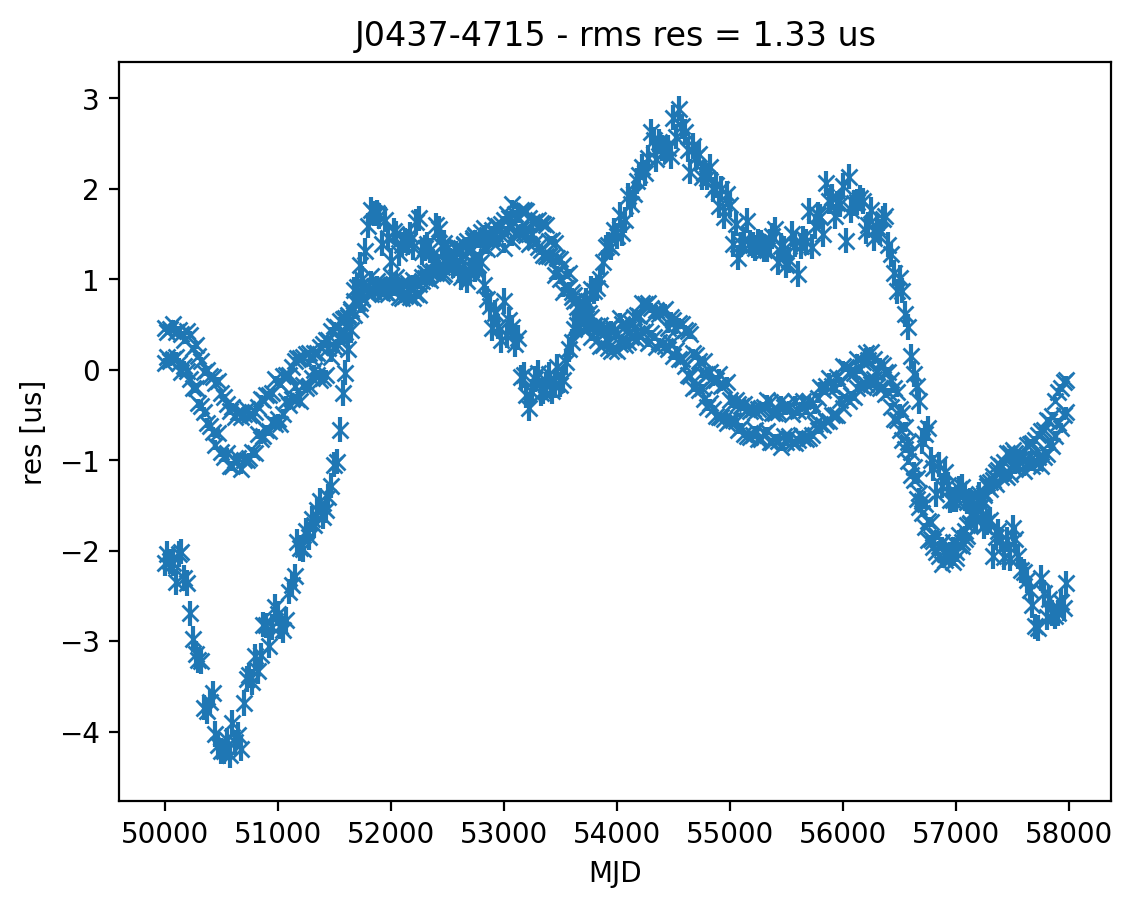

In [ ]:
LP.plotres(base_psr)

<div style="background-color:#D6EAF8; color:#000; padding:12px; border-left:6px solid #2874A6; border-radius:4px;">
<b>Question:</b> What noise process do you think is dominant in this pulsar? What features in the residuals are you basing that on?
</div>

<details>
<summary><b>Click to reveal the answer</b></summary>

<br>

Look at the shape of the residuals, not just their size. Two things stand out:

- **Red noise:** the points wander smoothly over thousands of days rather than scattering randomly, with broad peaks and troughs on multi-year timescales. Nearby points are strongly correlated. That slow wandering is the signature of **red noise**.

- **Chromaticity:** look at the early part of the dataset (MJD 50000 to 52000), where the residuals split into separate tracks that sit at different levels. Those tracks are the different observing frequencies (600, 1400, 3200 MHz). If the noise were purely achromatic, all frequencies would overlap. The fact that they separate, and that the separation changes over time, is the fingerprint of **chromatic** noise (dispersion measure variations, plus solar wind because J0437 sits near the ecliptic).

So J0437's residuals are dominated by red noise, with a clear chromatic component on top of the underlying white scatter

</details>

To study each noise source in isolation, we first need a clean slate. The `make_ideal` function removes the computed residuals from the TOAs, giving us (in effect) a perfect realisation of the deterministic timing model: the residuals become essentially zero.

From this clean baseline, we can inject one noise process at a time and see exactly what it contributes, without the real noise getting in the way. We will call `make_ideal` many times throughout this tutorial, each time resetting the pulsar before injecting something new.

In [2]:
LT.make_ideal(base_psr)
plt.figure(figsize=(16, 6))
LP.plotres(base_psr)

NameError: name 'LT' is not defined

## 3. White noise: the cicadas in the grass

Now we start injecting noise into our clean pulsar, one process at a time, and watch what each does to the residuals.

We begin with **white noise**: scatter that is uncorrelated from one TOA to the next. It is the constant background hum of the savanna. White noise has three flavours, and we will meet each in turn:

- **EFAC**: a scaling of the reported TOA uncertainties.
- **EQUAD**: extra white noise added in quadrature.
- **ECORR (jitter)**: white noise correlated within an observing epoch.

The two main physical origins are *radiometer noise* (thermal noise in the telescope) and *pulse jitter* (intrinsic pulse-to-pulse shape variation).

### Radiometer noise and EFAC

During each observing session, which can last from a few minutes to several hours, the recorded pulses are first *de-dispersed* (corrected for the frequency-dependent delay caused by the interstellar medium) and then *folded* (stacked at the pulsar's spin period to build an averaged pulse profile). This averaged profile is matched against a long-term template to determine the time of arrival (TOA).

The standard TOA uncertainties (the error bars) come from this template-matching step and reflect only the uncertainty in the fit. Not all sources of error are captured this way. To account for the rest, we apply a multiplicative correction called the **EFAC** (Extra FACtor), which scales the reported uncertainties up or down to better reflect the true measurement scatter.

Here we add an EFAC of 1.0, meaning the injected scatter has an RMS equal to the nominal TOA errors.

<div style="background-color:#D6EAF8; color:#000; padding:12px; border-left:6px solid #2874A6; border-radius:4px;">
Before running the next cell, what do you expect EFAC-only residuals to look like?
</div>

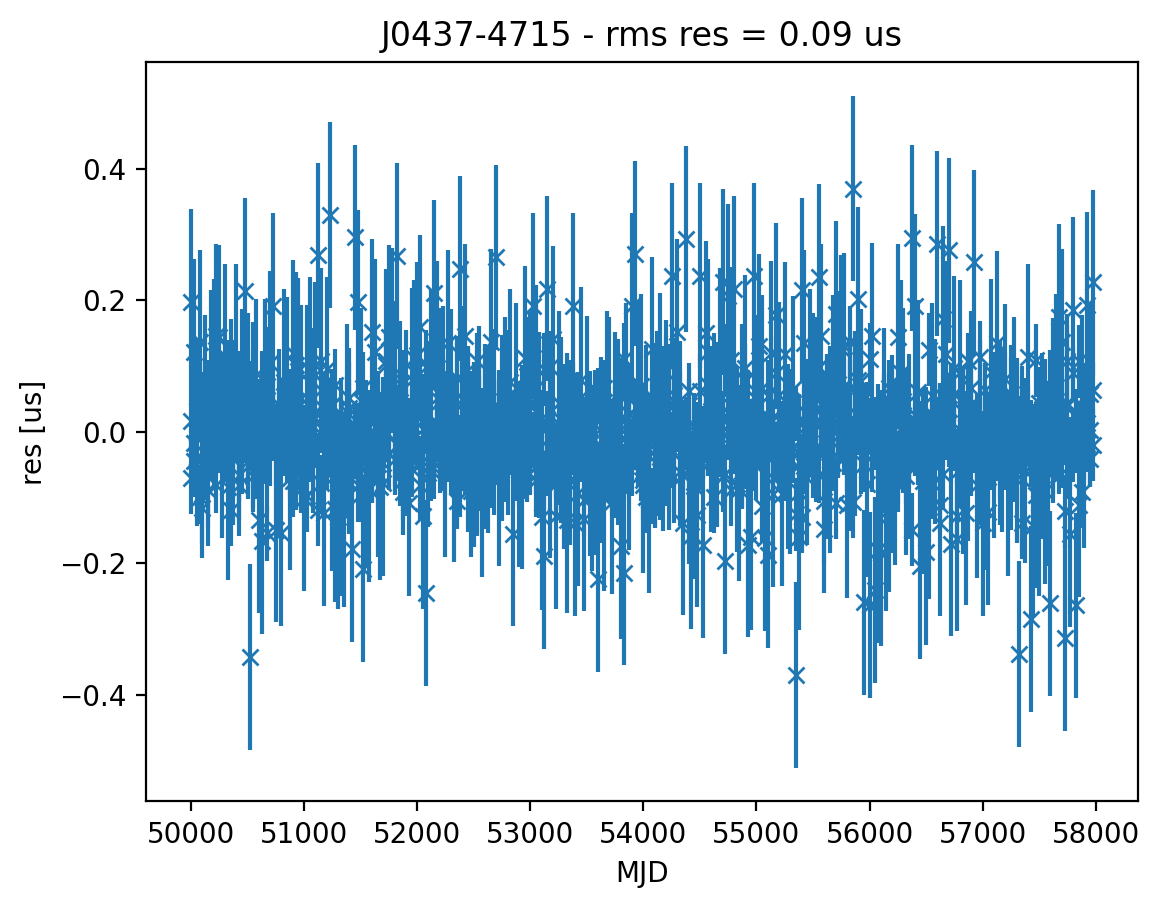

In [ ]:
LT.add_efac(base_psr,efac=1.0,seed=1234)
LP.plotres(base_psr)

You should see featureless random scatter with no trend, at roughly the microsecond level set by the TOA uncertainties. This is the signature of white noise: every point is independent of its neighbours.

### Jitter and ECORR

During an observing epoch, only a finite number of pulses are folded into the averaged profile. Small variations in the shape of that folded profile, due to the limited number of pulses, produce a type of white noise called *pulse phase jitter*.

Crucially, when we record multiple TOAs in nearby radio-frequency bands during the *same* observing epoch, they come from the same set of folded pulses, so their jitter is correlated. This gives rise to **ECORR** (Extra CORRelated) white noise: uncorrelated between epochs, but correlated within an epoch. This is the block-diagonal $U J U^{T}$ term from the maths above.

Below we show what jitter alone looks like.

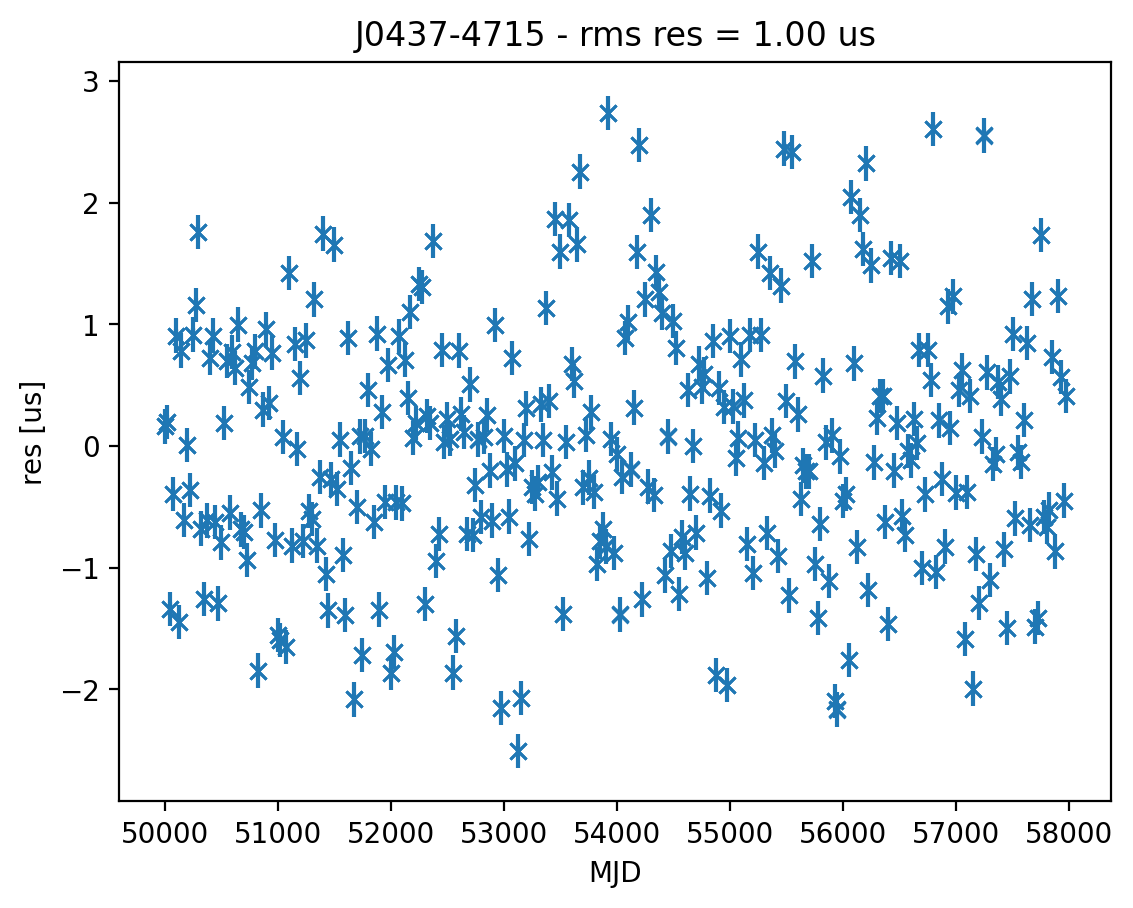

In [ ]:
LT.make_ideal(base_psr)
LT.add_jitter(base_psr,1e-6) # 1 microsecond of jitter
LP.plotres(base_psr)

### EQUAD

Sometimes there is extra white noise beyond the formal TOA uncertainties, which can absorb unmodelled instrumental, calibration, template-matching, or other short-timescale effects. To account for these additional contributions to the TOA scatter, we include an **EQUAD** (Extra QUADrature) term, so called because it adds in quadrature to the existing uncertainties.

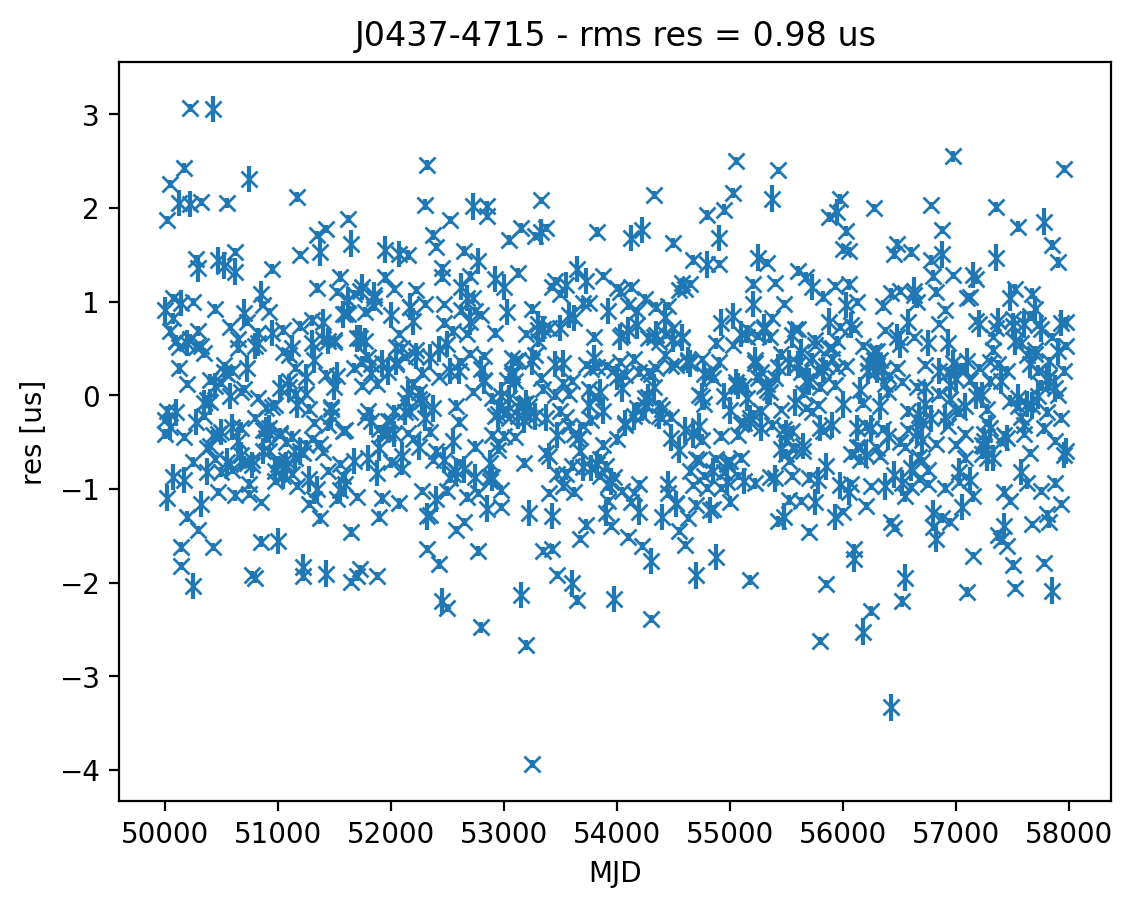

In [ ]:
LT.make_ideal(base_psr)
LT.add_equad(base_psr,1e-6) # 1 microsecond of jitter
LP.plotres(base_psr)

### All together

Each white noise term on its own just looks like scatter. In real data they might be present all at once. Let's reset the pulsar and inject EFAC, jitter, and EQUAD together to see the combined white noise budget.

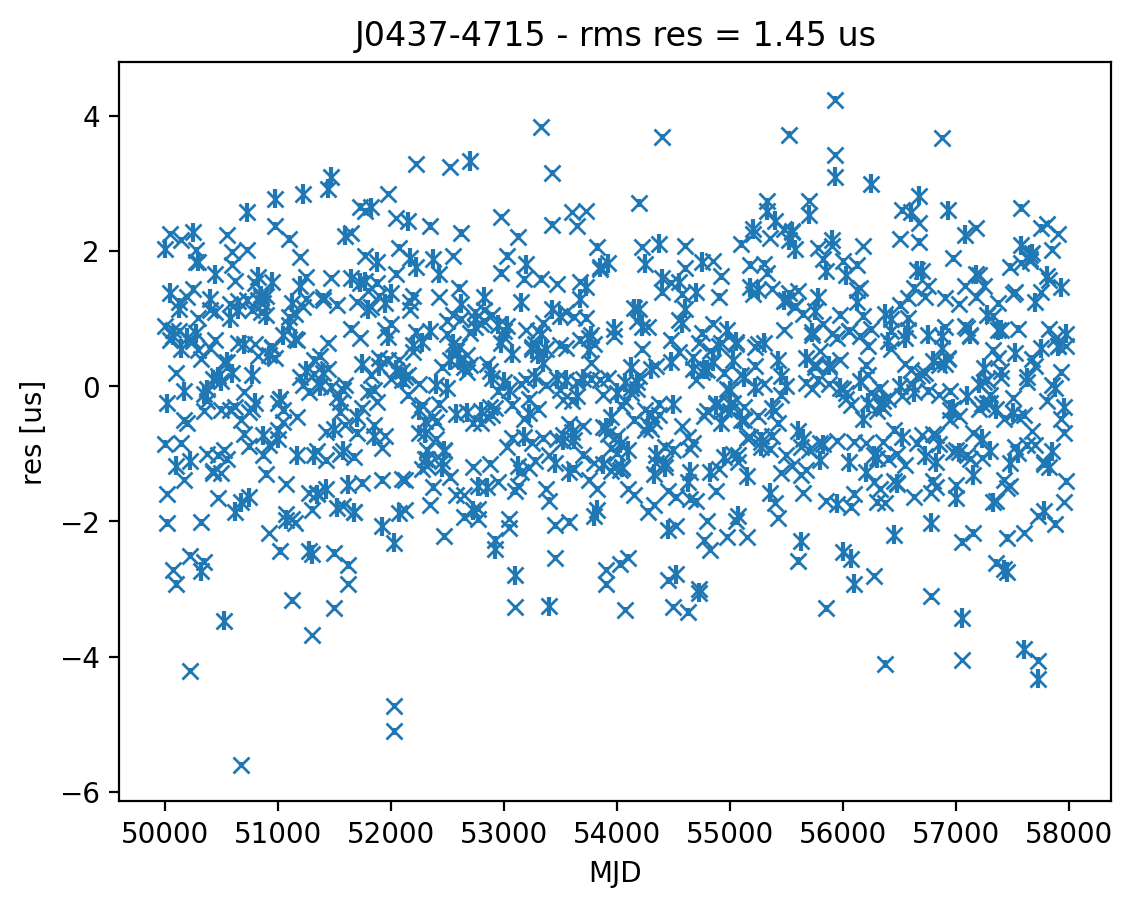

In [ ]:
seed = 1234
LT.make_ideal(base_psr)
LT.add_efac(base_psr, efac=1.0, seed=seed)
LT.add_jitter(base_psr, 1e-6, seed=seed)
LT.add_equad(base_psr, 1e-6, seed=seed)
LP.plotres(base_psr)

<div style="background-color:#D6EAF8; color:#000; padding:12px; border-left:6px solid #2874A6; border-radius:4px;">
<b>Question:</b> all three white noise terms produce featureless scatter. If they all look the same in the residuals, how do you think we tell them apart in real data?
</div>

<details>
<summary><b>Click for the answer</b></summary>

<br>

The three white noise terms are genuinely indistinguishable by eye in a single residual plot. They all produce featureless, uncorrelated scatter. What separates them is how their variance depends on observing conditions:

**EFAC** scales with the existing TOA uncertainty σᵢ. A TOA that already had a large error bar gets proportionally more EFAC noise. So EFAC noise is large where the radiometer noise is large (faint observations, short integrations) and small where the data are good. Its contribution to the variance is E²σᵢ².

**EQUAD** adds a constant variance Q² to every TOA regardless of its original uncertainty. So it dominates the *good* TOAs (small σᵢ) and is negligible for the *bad* ones. This opposite dependence on σᵢ is what lets a fit separate EQUAD from EFAC: they respond differently across the range of TOA uncertainties.

**ECORR** is distinguished not by its dependence on σᵢ but by its *correlation structure in time*. TOAs taken in the same observing epoch (same day, different frequency bands) share the same jitter realisation, while TOAs from different epochs are independent. If you have simultaneous multi-frequency observations, you can see this: the residuals at different frequencies move together within an epoch. A single-frequency dataset cannot distinguish ECORR from EQUAD at all.

So the way we tell them apart is statistical, not visual. We write down the covariance matrix N with all three parameters, and infer E, Q, and the ECORR amplitude c from how the scatter varies with TOA uncertainty and across epochs.

</details>

## 4. Achromatic red noise: the rhino trail

Time to meet a heavier set of tracks in our timing safari. **Timing noise** — also called *spin noise* — is achromatic red noise: it is correlated in time, but it does not depend on observing frequency.

It is thought to come from irregularities in the neutron star's rotation: tiny, slow wanderings in the spin rate that accumulate into low-frequency structure in the residuals.

Like a rhino moving through the savanna, timing noise leaves broad, slow trails. Unlike white noise, which scatters each point independently, red noise makes nearby points move together. The result is the smooth, drifting structure you already spotted in J0437's real residuals.

Let's put all the white-noise terms back, then add achromatic red noise on top, to see the full picture.

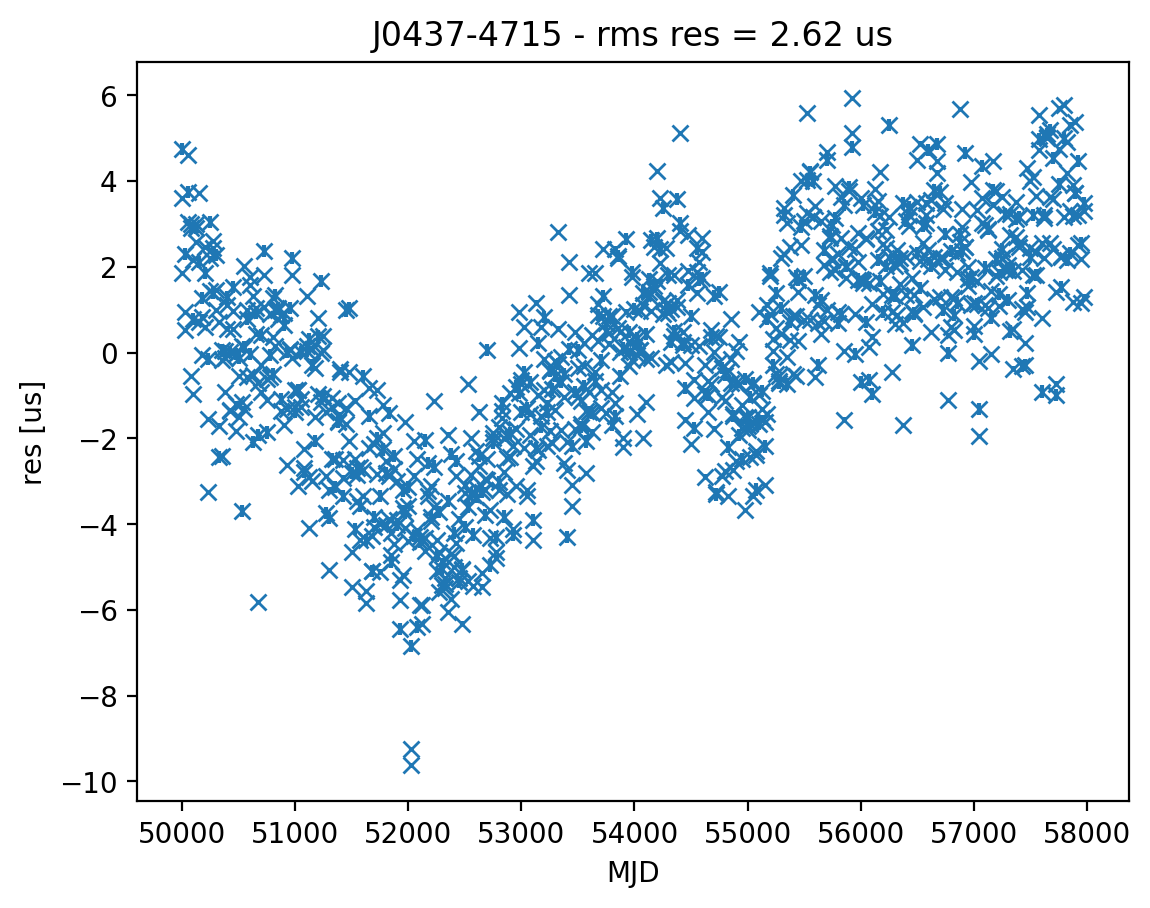

In [ ]:
seed = 1234
LT.make_ideal(base_psr)
LT.add_efac(base_psr, efac=1.0, seed=seed)
LT.add_jitter(base_psr, 1e-6, seed=seed)
LT.add_equad(base_psr, 1e-6, seed=seed)
# Simulating timing noise (achromatic red noise)
LT.add_rednoise(base_psr, 7e-14, 2.5, seed=seed)
LP.plotres(base_psr)

You still see the familiar white scatter, but now riding on a slow, wandering baseline. The white noise sets the point-to-point jitter; the red noise sets the smooth, large-scale drift.

### Exercise

Simulate a pulsar with **only EFAC and timing noise** (no jitter, no EQUAD). Use the same parameter values and the same seed as the cell above, so you can compare directly. Fill in the cell below.

<div style="background-color:#D6EAF8; color:#000; padding:12px; border-left:6px solid #2874A6; border-radius:4px;">
<b>Question:</b> How do the residuals look with only EFAC and red noise? Compared to the previous plot with all the white noise terms, what has changed, and what has stayed the same?
</div>

<details>
<summary><b>Click to reveal the answer</b></summary>

<br>

The slow, wandering red-noise baseline is unchanged: it is set entirely by `add_rednoise`, which you ran with the same amplitude, spectral index, and seed. What changes is the point-to-point scatter on top of it. With only EFAC, the white scatter is slightly smaller than before, because you have removed the jitter and EQUAD contributions that were adding extra variance to each TOA.

So, the red noise controls the *shape* of the long-term wandering, while the white noise terms control the *thickness* of the band around it.

</details>

### How the spectral index shapes the noise

Recall the power-law form of the red noise spectrum: the power at Fourier frequency $f_n$ goes as $(f_n/f_{ref})^{-\gamma}$, where $\gamma$ is the **spectral index**. A larger $\gamma$ means relatively more power at low frequencies, so the residuals wander more slowly and more smoothly. A smaller $\gamma$ spreads power toward higher frequencies, giving faster, choppier wandering.

Let's inject red noise with the same amplitude but two different spectral indices and plot them side by side.

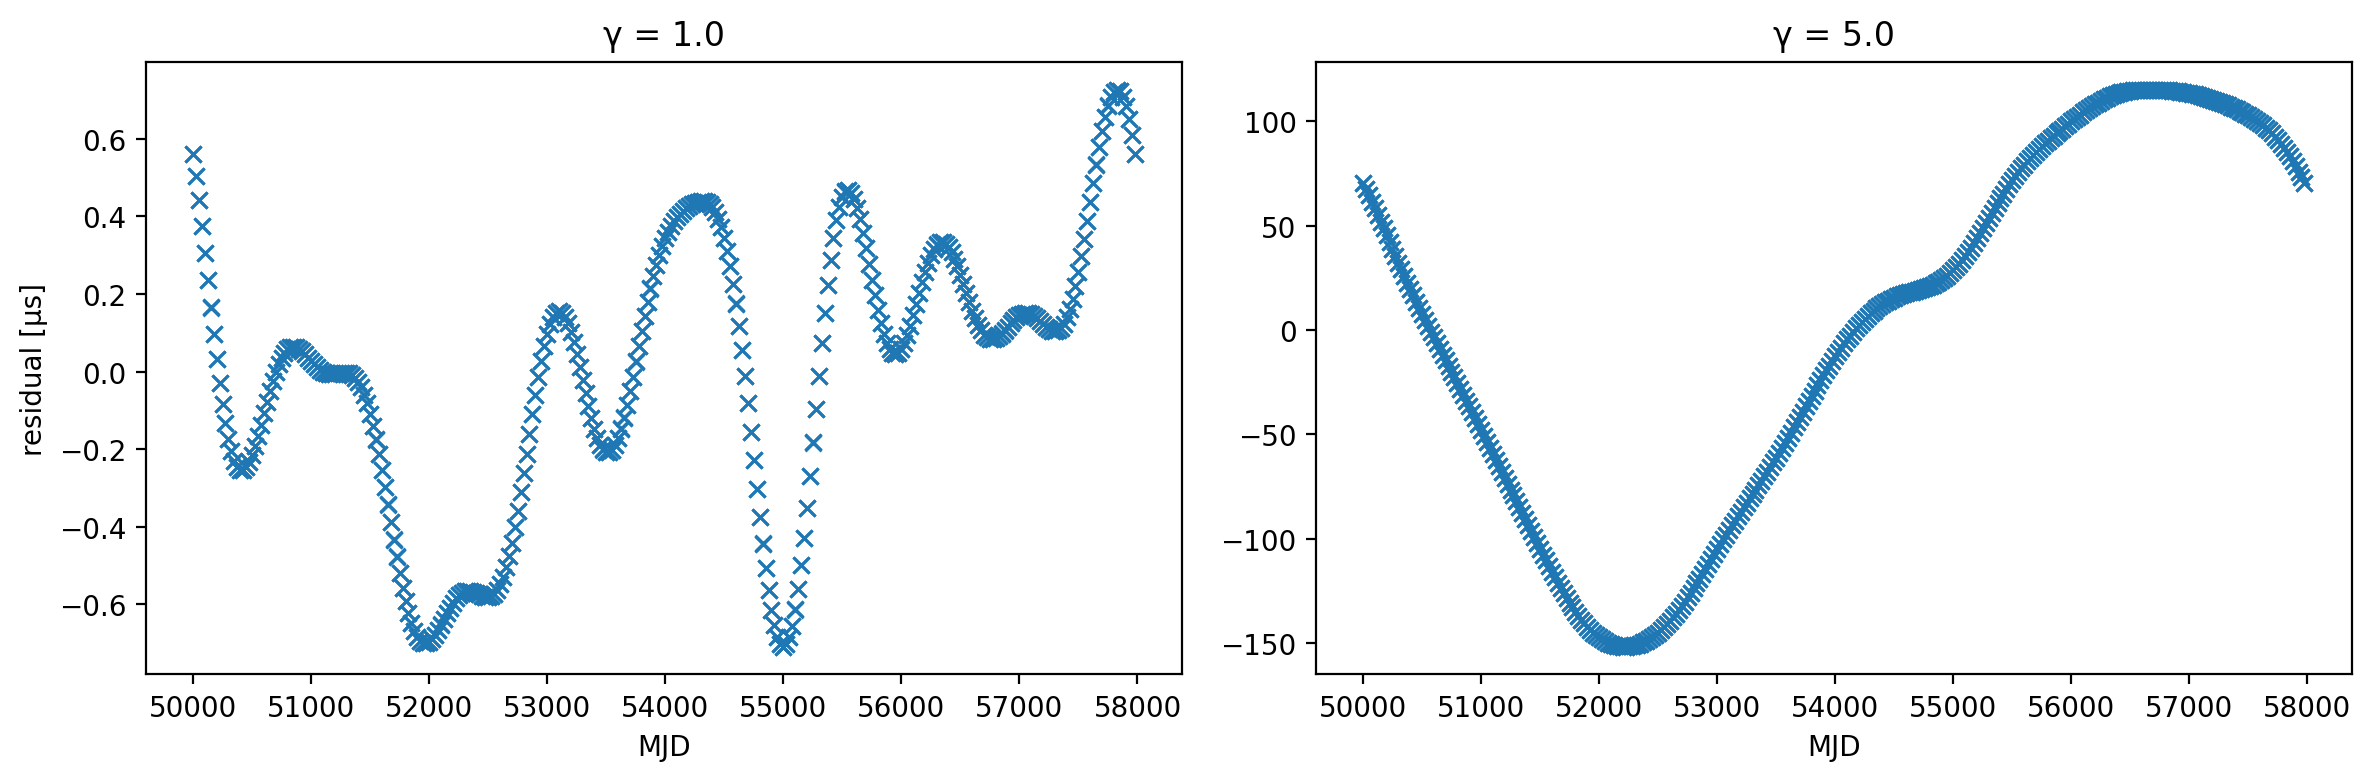

In [ ]:
import matplotlib.pyplot as plt

gammas = [1.0, 5.0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

for ax, gamma in zip(axes, gammas):
    LT.make_ideal(base_psr)
    LT.add_rednoise(base_psr, 7e-14, gamma, seed=1234)
    t = base_psr.toas()
    res = base_psr.residuals() * 1e6  # convert to microseconds
    ax.plot(t, res, 'x')
    ax.set_title(f"γ = {gamma}")
    ax.set_xlabel("MJD")

axes[0].set_ylabel("residual [µs]")
plt.tight_layout()
plt.show()

Both panels have the same red-noise amplitude, but the spectral index gives them very different character. Note the y-axis scales differ between the two panels.

At $\gamma=1$ (shallow spectrum), the power is spread fairly evenly across frequencies, so the residuals are choppy, with several wiggles on timescales of a few thousand days. At $\gamma=5$ (steep spectrum), almost all the power sits at the lowest frequencies, so the residuals trace a single large, smooth swing across the whole dataset. Notice also the scale: the steep spectrum produces a far larger total amplitude (hundreds of $\mu s$ versus under 1 $\mu s$), because low-frequency power dominates the variance.

So, a steeper spectral index concentrates power at low frequencies, giving slower, smoother, and larger wandering. The gravitational wave signal we are hunting has a specific, steep spectral index of $\gamma = 13/3 \approx 4.33$.

> **A note on the plot:** the panels above use `sharey=False`, so each one auto-scales to its own range. This is what reveals the *shape* of the γ = 1 wandering, which would otherwise be flattened into a near-straight line. Try changing it to `sharey=True` and re-running the cell. The γ = 5 swing will dominate the shared scale and the γ = 1 panel will look almost flat.

## 5. Chromatic red noise: the chameleon

The red noise we just met was *achromatic*: it shifted every TOA the same way regardless of observing frequency. **Chromatic** noise is different. Like a radio chameleon, it changes its appearance depending on the frequency band you observe it in. The delay it introduces depends on the radio frequency $\nu$ of each TOA, scaling as $\nu^{-\beta}$, where $\beta$ is the chromaticity index.

This frequency dependence is both a nuisance and a gift. A nuisance because it adds structure to the residuals, but a gift because it gives chromatic noise a distinctive fingerprint: if we observe the same pulsar at several frequencies, chromatic noise separates the bands while achromatic noise (and a gravitational wave) does not. This is one of the main reasons pulsars are timed at multiple frequencies

We will look at three chromatic processes: dispersion measure variations, generic chromatic noise, and the solar wind.

### Dispersion measure variations

The dominant chromatic process is **dispersion measure (DM)** variation. As the radio pulse travels through the ionised interstellar medium, lower frequencies are delayed more than higher ones, with a delay scaling as $\nu^{-2}$ (cold-plasma dispersion, $\beta = 2$). The total electron column density along the line of sight changes over time as the medium drifts, so the dispersive delay wanders too.

Let's inject DM noise and see how it separates the observing frequencies.

<div style="background-color:#D6EAF8; color:#000; padding:12px; border-left:6px solid #2874A6; border-radius:4px;">
The data are at 600, 1400, and 3200 MHz. Before running the cell, which frequency do you expect to show the largest residuals, and which the smallest?
</div>

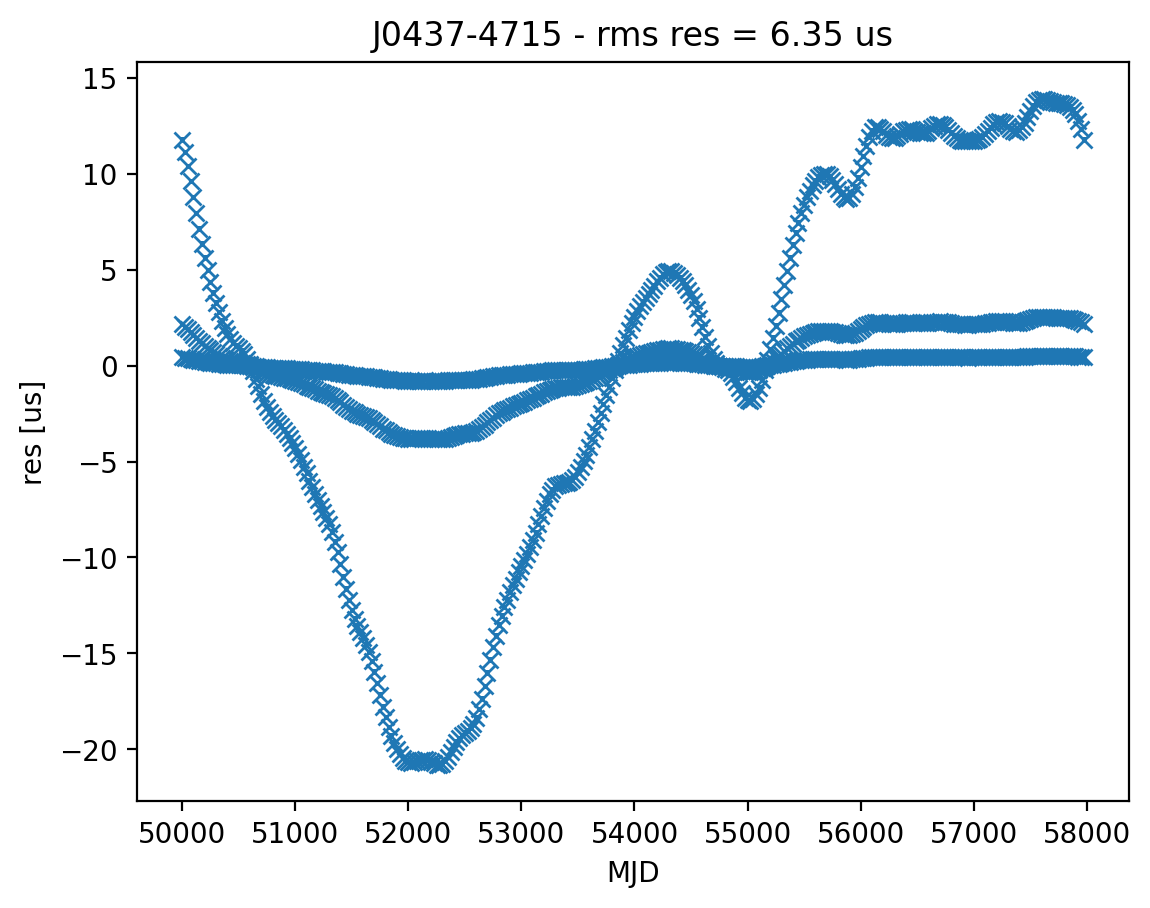

In [ ]:
LT.make_ideal(base_psr)
add_dm(base_psr, 2e-14, 3.3, seed=1234)
LP.plotres(base_psr)

<div style="background-color:#D6EAF8; color:#000; padding:12px; border-left:6px solid #2874A6; border-radius:4px;">
<b>Question:</b> you should see the residuals split into three bands. Which band is the 600 MHz data, which is 1400 MHz, and which is 3200 MHz? Why?
</div>

<details>
<summary><b>Click to reveal the answer</b></summary>

<br>

The dispersive delay scales as $\nu^{-2}$, so lower frequencies are delayed far more than higher ones. This means:

- **600 MHz** shows the **largest** residuals (lowest frequency, most delay). The $\nu^{-2}$ scaling makes this band's wandering several times larger than the others.
- **1400 MHz** shows intermediate residuals.
- **3200 MHz** shows the **smallest** residuals (highest frequency, least delay), almost flat by comparison.

The ratio of amplitudes between bands follows directly from the $\nu^{-2}$ law: going from 1400 to 600 MHz multiplies the delay by (1400/600)² ≈ 5.4, and going from 1400 to 3200 MHz divides it by (3200/1400)² ≈ 5.2. This characteristic frequency scaling is exactly how DM variations are identified and removed in real data.

</details>

### Generic chromatic noise

DM is not the only chromatic process. Scattering in the interstellar medium and various instrumental effects produce chromatic noise with a *different* frequency dependence, often steeper than $\nu^{-2}$. Our `add_ch` function lets us set the chromaticity index by hand. Below we use $\beta = 4.4$, which is typical of scattering.

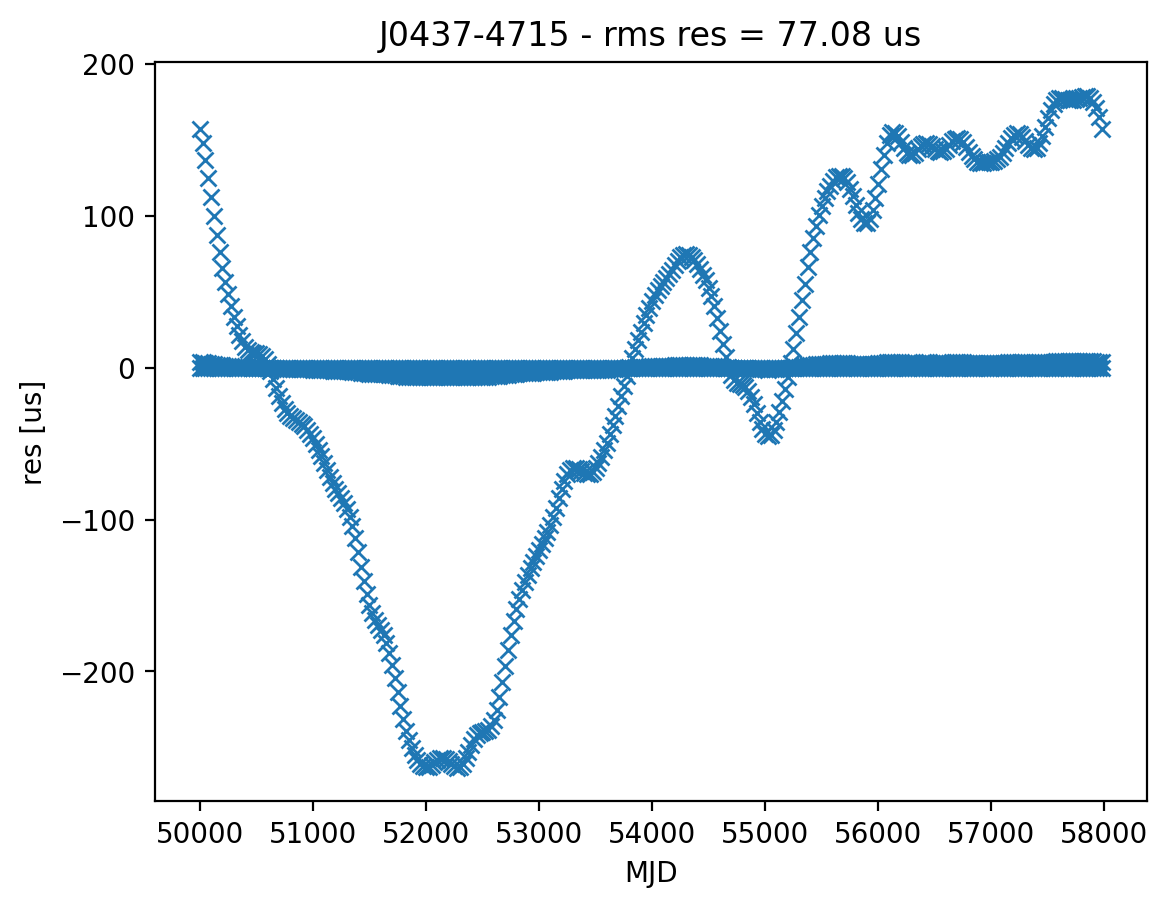

In [ ]:
LT.make_ideal(base_psr)
add_ch(base_psr,5e-14,3, idx=-4.4, seed=1234)
LP.plotres(base_psr)

The residuals again split by frequency, but the bands are now spread *further apart* than for DM. With the steeper $\nu^{-4}$ scaling, the lowest frequency is delayed even more dramatically relative to the highest. The steeper the chromaticity index β, the more extreme the separation between bands.

### Solar wind: a hot wind across the trail

The **solar wind** is a special case of chromatic noise. The Sun continuously emits a stream of ionised plasma. When our line of sight to the pulsar passes close to the Sun, the pulse travels through this extra plasma and picks up an additional dispersive delay. Because the closest approach happens once per orbit, the effect carries a strong **annual** signature.

The solar wind is split into two parts:

- A **deterministic** annual signal from the roughly steady mean electron density at 1 AU. This is predictable, so it is absorbed into the *timing model* as a fitted parameter (`NE_SW`, which you saw in the `.par` file). It is not noise.
- A **stochastic** part, from variations in the electron density (the solar cycle, coronal mass ejections, and so on). These are unpredictable, so they are modelled as a chromatic red-noise process. This is the part we are simulating here.

The `add_sw` function injects this stochastic part: the once-per-year geometric envelope, modulated by a red-noise process so its amplitude wanders from year to year.

> **Side note:** how strong the solar wind is for a *given* pulsar depends on its ecliptic latitude. If a pulsar sits close to the ecliptic plane, its line of sight passes especially near the Sun each year, making it more susceptible to solar wind than a pulsar far from the ecliptic. In our simulation, the overall strength is controlled by the `A` argument, but the pulsar's geometry still matters: the injected signal is modulated by the Earth-Sun-pulsar angle.

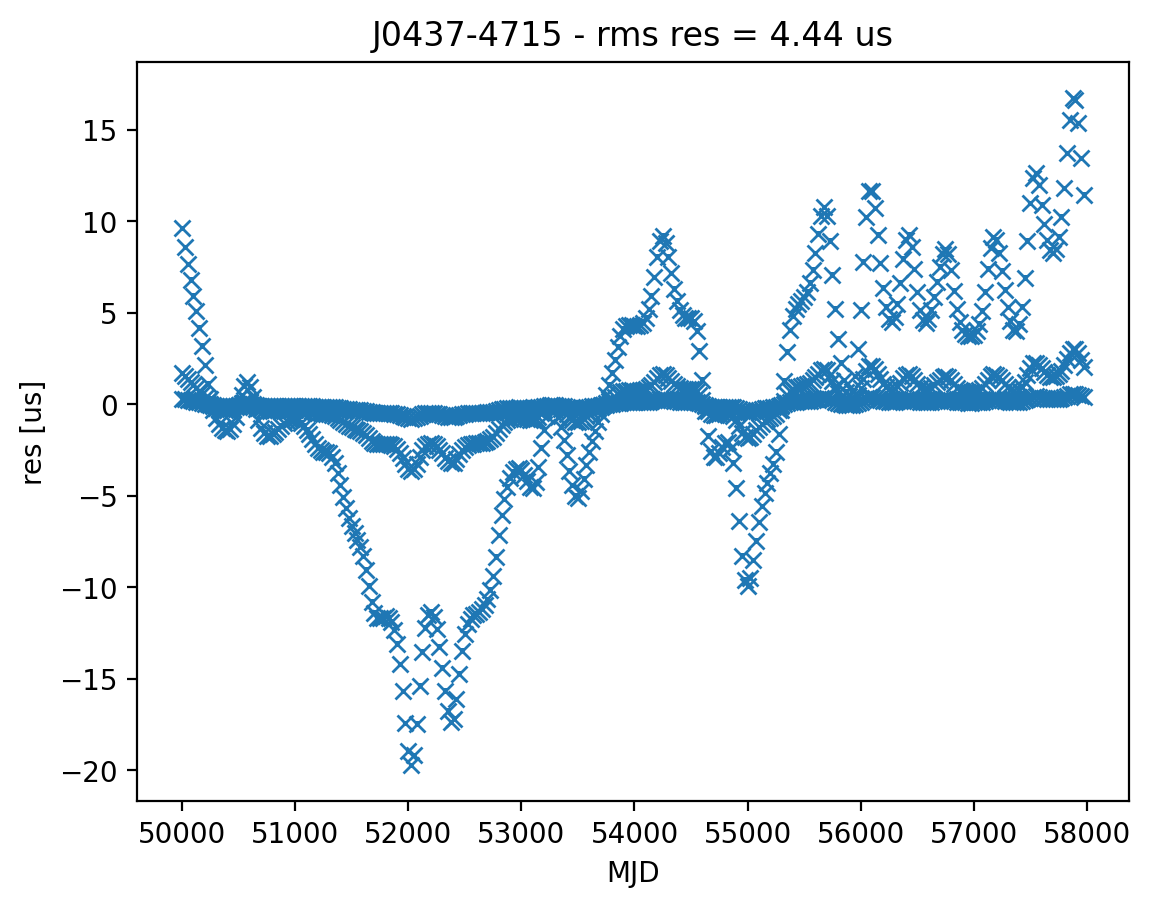

In [ ]:
LT.make_ideal(base_psr)
add_sw(base_psr,5e-6,2, seed=1234)
LP.plotres(base_psr)

<div style="background-color:#D6EAF8; color:#000; padding:12px; border-left:6px solid #2874A6; border-radius:4px;">
<b>Question:</b> in the plot you should be able to see two things at once: sharp once-per-year spikes, and a slow drift in how big those spikes are. Can you identify both? Which part would a steady <code>NE_SW</code> parameter remove, and which part is left as stochastic noise?
</div>

<details>
<summary><b>Click to reveal the answer</b></summary>

<br>

The sharp yearly features come from the solar-wind geometry: once per year, the line of sight is most sensitive to the Sun.

In this simulation, that geometric pattern is multiplied by a stochastic red process, so the size of the features can drift over time.

A steady <code>NE_SW</code> parameter would remove only the constant, predictable solar-wind contribution: the part with fixed amplitude and <code>ν⁻²</code> frequency scaling. The time-variable part injected by <code>add_sw</code> would remain as chromatic stochastic noise.

</details>

## 6. The gravitational wave background: the big-game sighting

A stochastic **gravitational wave background (GWB)**, produced by the combined signal of many supermassive black hole binaries across the universe, stretches and squeezes the space between us and each pulsar. That changes the pulse arrival times, leaving an imprint in the residuals.

Like timing noise, the GWB is an *achromatic red-noise* process: it does not depend on observing frequency, and it has a power-law spectrum. As we have already mentioned above, the expected spectral index for a population of black hole binaries driven by gravitational wave emission is $\gamma = 13/3 \approx 4.33$, a steep, very red spectrum.

Let's inject one and look at it.

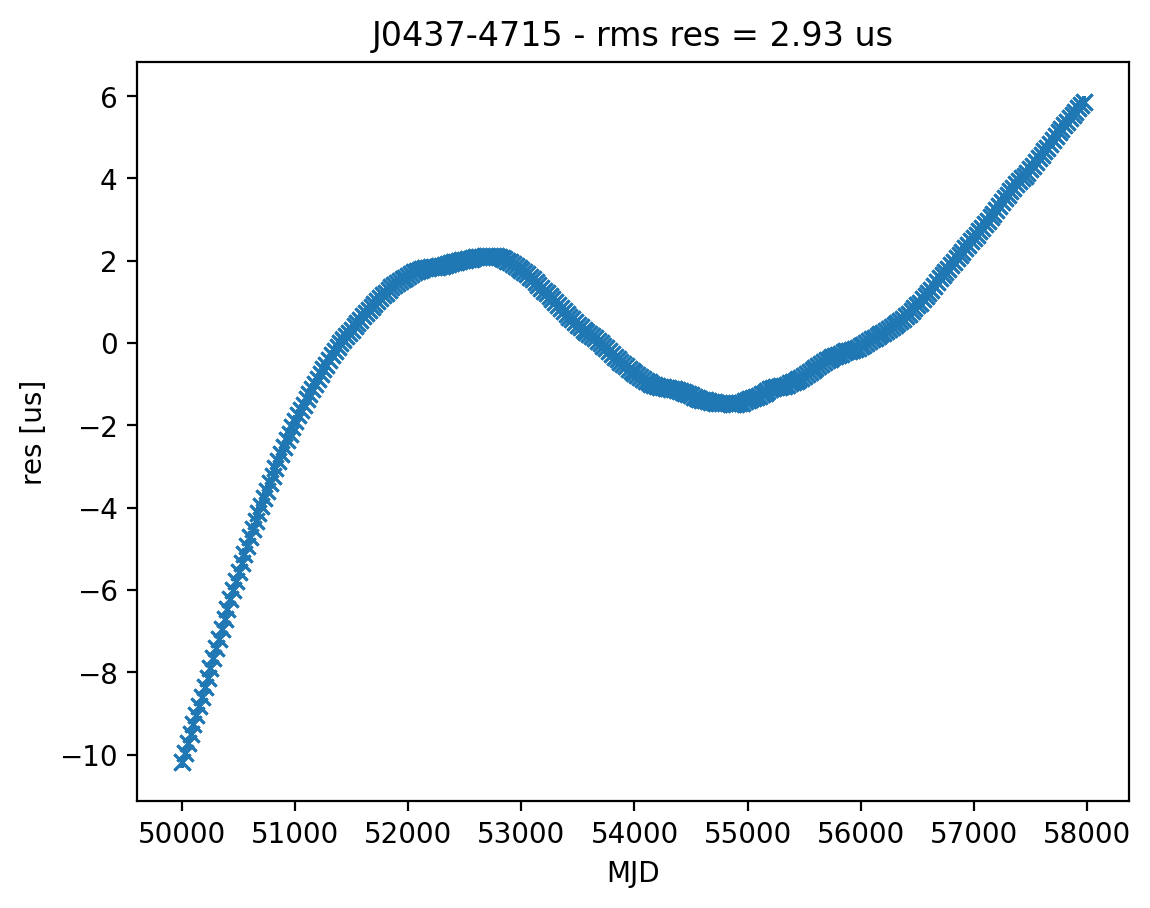

In [ ]:
LT.make_ideal(base_psr)
LT.createGWB([base_psr], Amp=5e-15, gam=13./3., seed=42)
LP.plotres(base_psr)

You can see a slow, smooth, red wandering, exactly the samae long-timescale structure we saw for timing noise. And that is the whole problem.

In a single pulsar, a gravitational wave background is **indistinguishable** from achromatic timing noise. Both are achromatic, both are red, both have power-law spectra. Looking at one pulsar's residuals, you simply cannot tell whether the red wandering is noise intrinsic to that neutron star, or the signature of gravitational waves passing through.

### The central problem: leopard or cheetah?

To drive this home, let's inject **timing noise** into the pulsar, and separately inject a **gravitational wave background**, using the *same steep spectral index* $\gamma = 13/3$ for both. In a single pulsar, these two signals can be like a leopard and a cheetah: similar at first glance, but not the same animal.

If they are truly degenerate in one pulsar, the two plots should look like the same kind of process.

Timing noise std [µs]: 4.498651000828505299
GWB std [µs]: 2.9296457519407711446


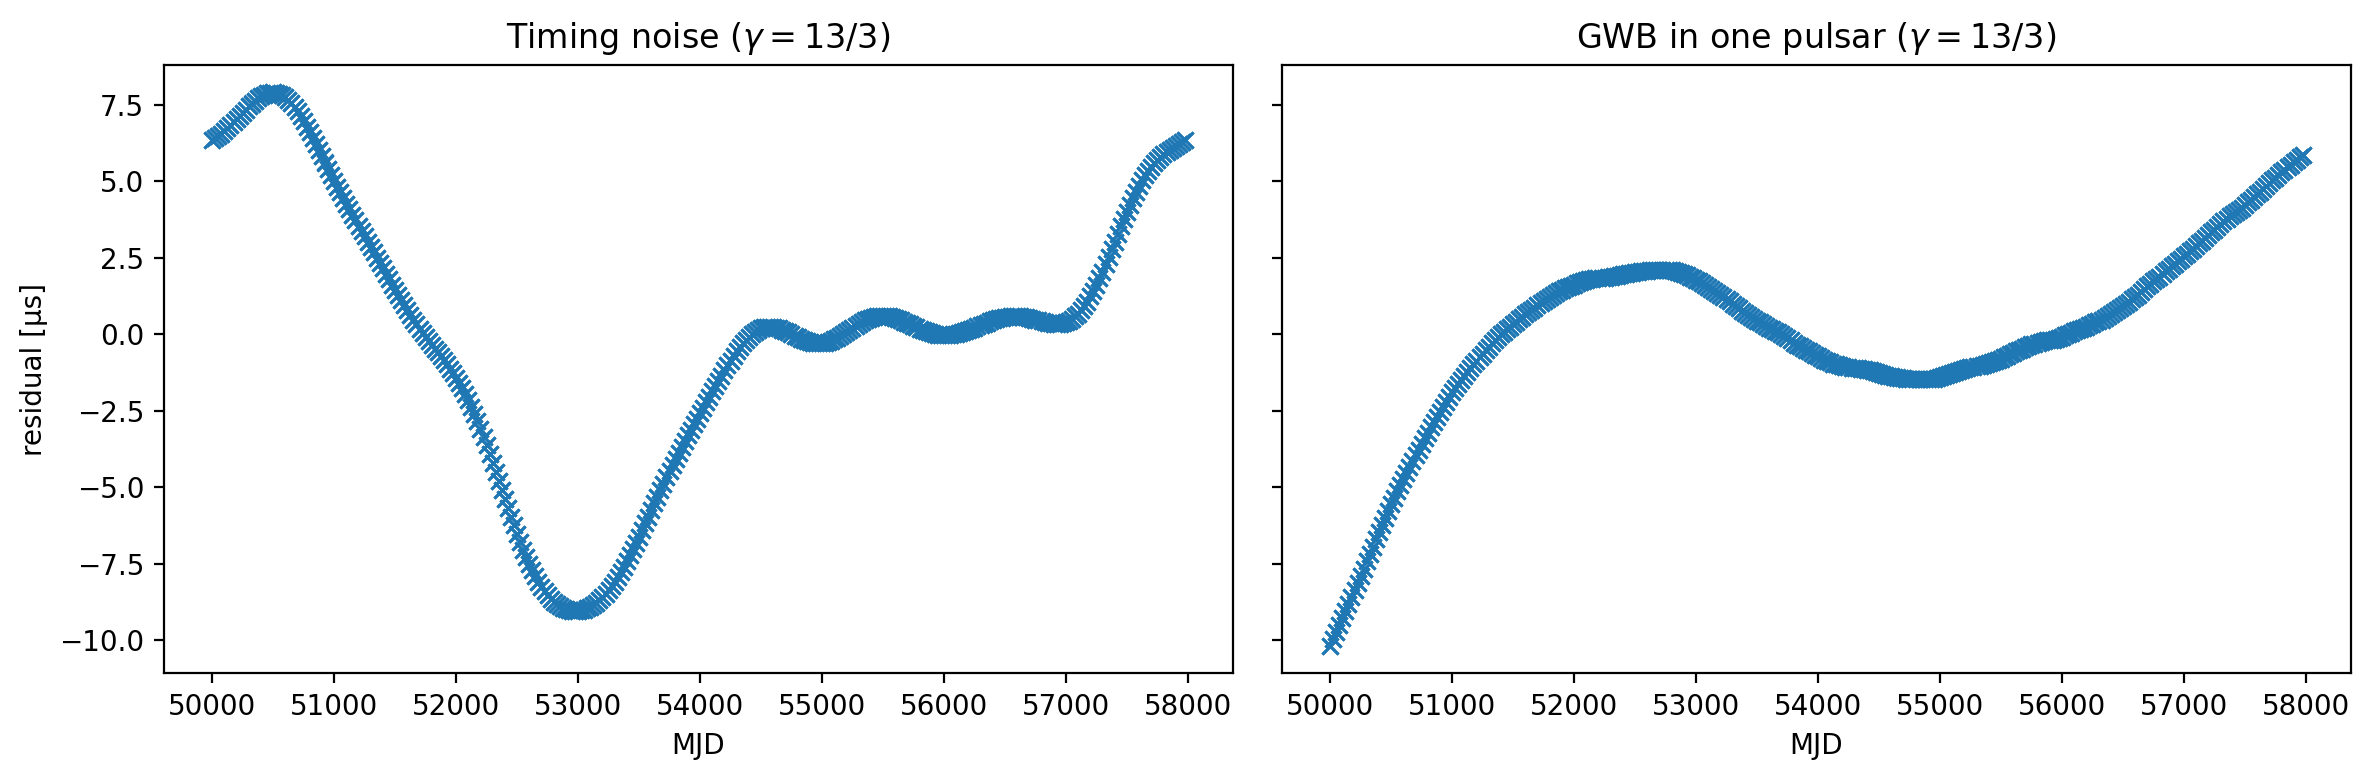

In [ ]:
gamma = 13 / 3

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

LT.make_ideal(base_psr)
LT.add_rednoise(base_psr,  2e-14, gamma, seed=42)
t = base_psr.toas()
res_tn = base_psr.residuals() * 1e6

axes[0].plot(t, res_tn, "x")
axes[0].set_title(r"Timing noise ($\gamma = 13/3$)")
axes[0].set_xlabel("MJD")
axes[0].set_ylabel("residual [µs]")

LT.make_ideal(base_psr)
LT.createGWB([base_psr], 5e-15, gam=gamma, seed=42)
t = base_psr.toas()
res_gwb = base_psr.residuals() * 1e6

axes[1].plot(t, res_gwb, "x")
axes[1].set_title(r"GWB in one pulsar ($\gamma = 13/3$)")
axes[1].set_xlabel("MJD")

print("Timing noise std [µs]:", res_tn.std())
print("GWB std [µs]:", res_gwb.std())

plt.tight_layout()
plt.show()

The two panels show the same kind of slow, red wandering. In a single pulsar, the two processes are degenerate.

So how do PTAs ever detect gravitational waves? The answer is **correlations between pulsars**. Timing noise is intrinsic to each neutron star, so it is *independent* from one pulsar to the next. A gravitational wave background, by contrast, affects all pulsars in a way that depends on the angle between them on the sky. Two pulsars close together on the sky respond similarly; two far apart respond differently. This specific angular pattern is called the **Hellings-Downs curve**.

By cross-correlating the residuals of many pulsars and looking for the Hellings-Downs pattern, we can pick out the gravitational wave background even though it is invisible in any single pulsar. That is the entire reason a pulsar timing *array* exists, rather than just timing one very good pulsar. We pursue this in the next notebook, `Common_signal_search.ipynb`.

<div style="background-color:#D6EAF8; color:#000; padding:12px; border-left:6px solid #2874A6; border-radius:4px;">
<b>Question:</b> if you had ten years of exquisite data on a single pulsar and saw a beautiful red-noise signal with γ = 13/3, could you announce a gravitational wave detection? Why or why not?
</div>

<details>
<summary><b>Click to reveal the answer</b></summary>

<br>

No. A single pulsar with red noise at γ = 13/3 is perfectly consistent with a gravitational wave background, but it is *equally* consistent with intrinsic timing noise that happens to have a similar spectrum. There is no way to tell them apart from one pulsar alone.

A detection requires showing that the red signal is *common* across many pulsars and, crucially, that the cross-correlations between pulsar pairs follow the Hellings-Downs angular pattern. Only the array, not any single pulsar, can make that case.

</details>

---

## 7. Build your own pulsar

So far we have taken a *real* pulsar (its `.par` and `.tim` files) and stripped it back to an ideal timing model before injecting noise. But we can also build a simulated pulsar entirely from scratch: take a timing model from a `.par` file, invent our own set of observation times, frequencies, and uncertainties, and create the TOAs ourselves. No `.tim` file required.

This is how you generate mock datasets for testing analysis pipelines, and it is exactly what we will do in the following exercise when we build an array of pulsars with an injected gravitational wave signal.

We start from the timing model in the `.par` file. We are going to:
- Simulate a fake pulsar observed at 3 radio frequencies (600, 1400, and 3200 MHz)
- Observe roughly every 30 days, with a little jitter in the cadence because real observations are not taken at perfectly regular intervals.
- Use the same observation times at each frequency
- Combine the TOAs into a single array
- Corresponding frequencies (MHz) and uncertainties (us) for each TOA

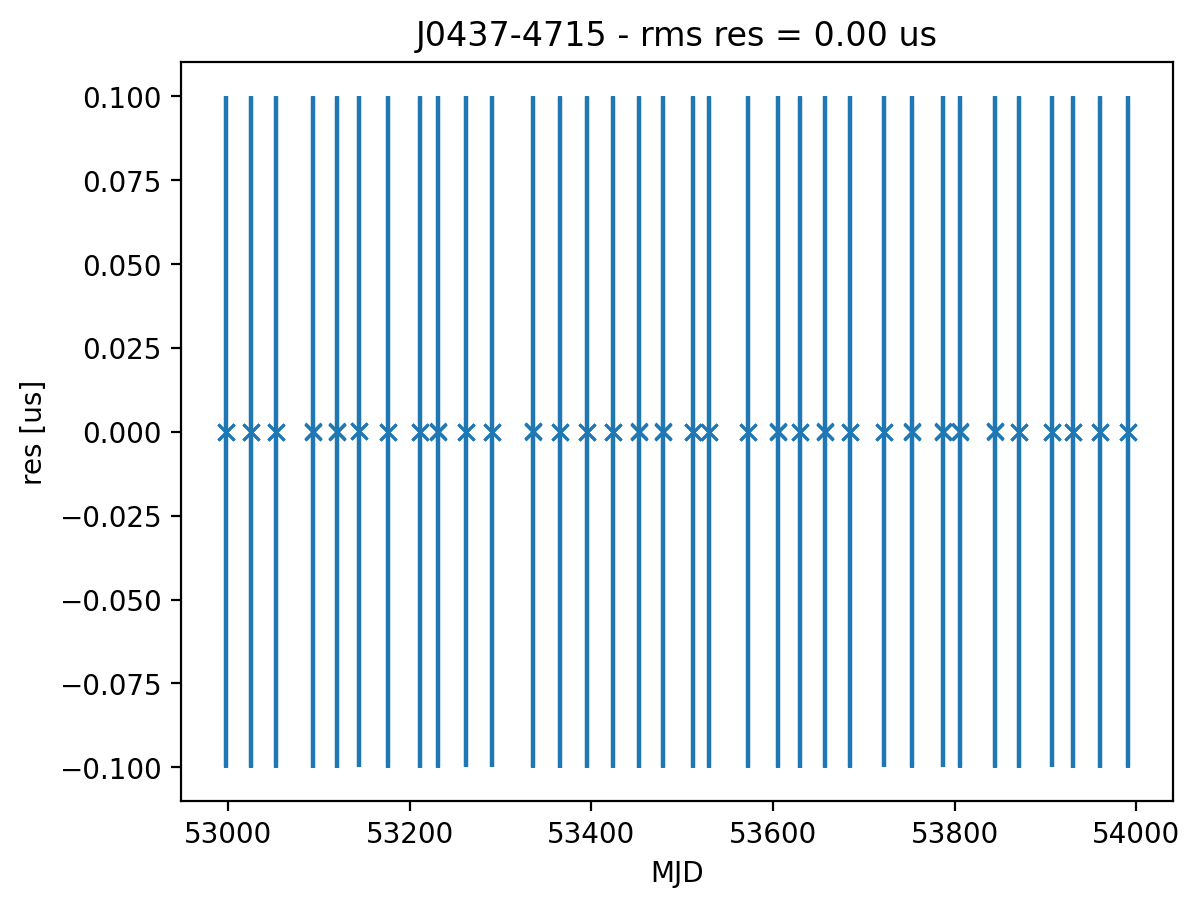

In [ ]:
# simulate from fake pulsar for 3 radio frequencies
obstimes = np.arange(53000, 54000, 30)
obstimes = (obstimes + np.random.uniform(-10, 10,
            size=obstimes.shape)).astype(int) #beacuse we dont'always observe exactly every 30 days

# define the observation times for all frequencies
obstimes_600 = obstimes
obstimes_1400 = obstimes
obstimes_3200 = obstimes

# Combine TOAs into a single array
combined_obstimes = np.concatenate([obstimes_600, obstimes_1400, obstimes_3200])

# Corresponding frequencies and errors for each TOA
combined_freq = np.concatenate([
    np.full(len(obstimes_600), 600),
    np.full(len(obstimes_1400), 1400),
    np.full(len(obstimes_3200), 3200)
])
combined_toaerr = np.concatenate([
    np.full(len(obstimes_600), 0.1),
    np.full(len(obstimes_1400), 0.1),
    np.full(len(obstimes_3200), 0.1)
])

parfile = datadir + 'J0437-4715.par'
fake_psr = LT.fakepulsar(parfile=parfile, obstimes=combined_obstimes,
                         toaerr=combined_toaerr, freq=combined_freq, observatory="pks", flags="-or pks")
LP.plotres(fake_psr)

Now let's inject some radiometer noise, timing noise, and dispersion measure into our fake pulsar.

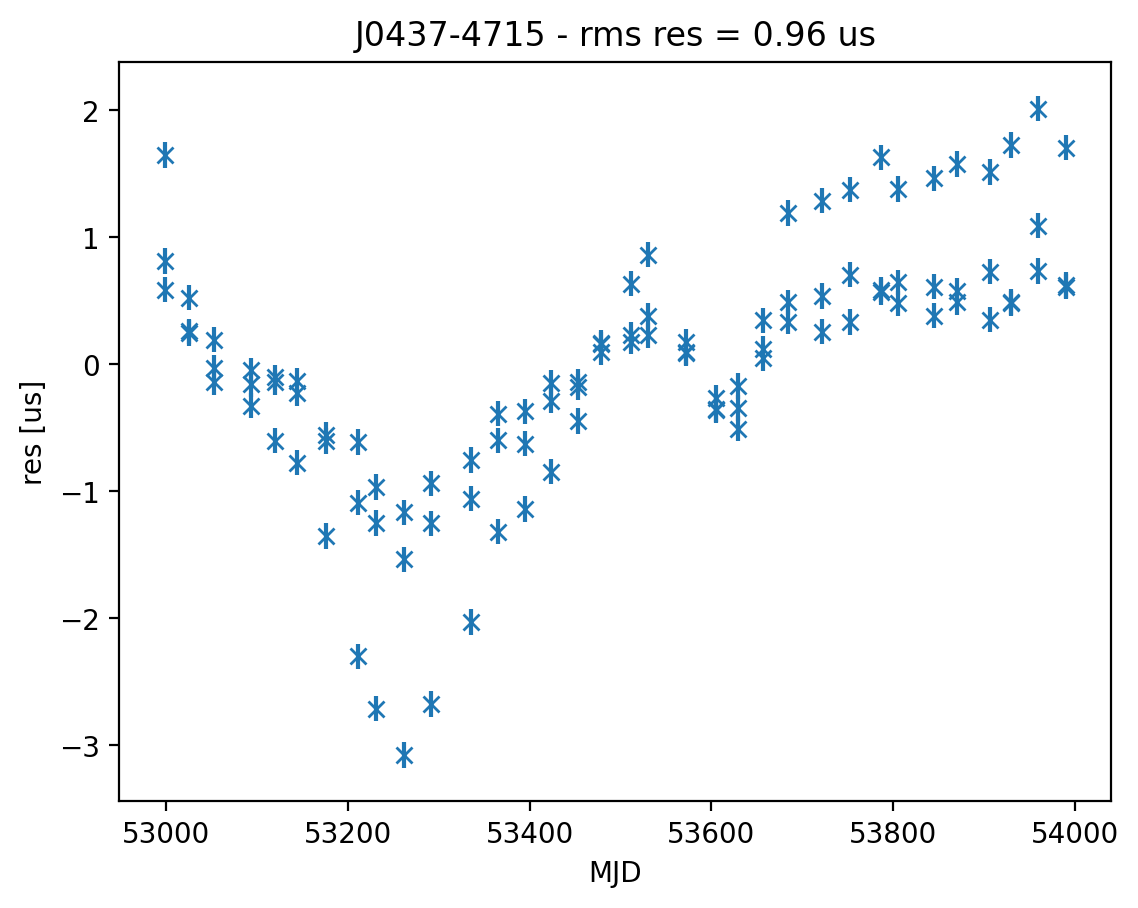

In [ ]:
add_dm(fake_psr, 2e-14, 3.3, seed=1234)
LT.add_efac(fake_psr, efac=1.0, seed=1234)
LT.add_rednoise(fake_psr, 7e-14, 2.5, seed=1234)
LP.plotres(fake_psr)

Finally, we can save our simulated pulsar to new `.par` and `.tim` files, so it can be loaded again later or fed into an analysis pipeline.

In [ ]:
outdir = 'output/'
os.makedirs(outdir, exist_ok=True)
fake_psr.savepar(outdir + 'J0437-4715_sim.par')
fake_psr.savetim(outdir + 'J0437-4715_sim.tim')



Results for PSR J0437-4715


RMS pre-fit residual = 0.000 (us), RMS post-fit residual = 0.962 (us)
Fit Chisq = 0	Chisqr/nfree = 0.00/0 = nan	pre/post = 0
Number of fit parameters: 0
Number of points in fit = 0
Offset: 0 0 offset_e*sqrt(n) = 0 n = 0


PARAMETER       Pre-fit                   Post-fit                  Uncertainty   Difference   Fit
---------------------------------------------------------------------------------------------------
RAJ (rad)       1.20979058355726          1.20979058355726          0             0             N
RAJ (hms)       04:37:15.8146878          04:37:15.8146878          0             0            
DECJ (rad)      -0.824709874239124        -0.824709874239124        0             0             N
DECJ (dms)      -47:15:08.62242           -47:15:08.62242           0             0            
F0 (s^-1)       173.687946184762          173.687946184762          1.7332e-14    0             Y
F1 (s^-2)       -1.72835289717769e-15     -1.72835289717769e-1

You now have all the tools to build a simulated pulsar with any combination of noise you like. In the final section, we put this to work.

## 8. Field exercises (bonus activity)

You have now met every animal in the noise savanna and seen how each one shapes the residuals. Time to go out and track them yourself. These exercises build from quick variations on what we have done, up to a full mock PTA analysis.

The data directory contains `.par` and `.tim` files for several pulsars, not just J0437. Use them to explore how noise looks for pulsars in different parts of the sky.

### Exercise: follow a different trail

Pick a different pulsar from the data directory and repeat some of the injections from this tutorial. In particular:

- **Solar wind and ecliptic latitude.** Find a pulsar that is *not* close to the ecliptic plane and inject solar wind into it, using the same amplitude `A` you used for J0437. How does the annual signal compare? (Recall from Section 5 that the geometric envelope depends on the pulsar's position, so a high-latitude pulsar should show a weaker, less spiky annual signal even at the same `A`.)
- **Shallow chromatic noise.** Inject chromatic noise with a very shallow spectral index (small $\gamma$). What does it look like compared to the steep cases?
- **The central degeneracy, again.** Inject red noise and a gravitational wave with the *same* spectral index into the same pulsar. Can you tell them apart from the residuals of this one pulsar alone? (You already know the answer from Section 6, but it is worth seeing it for yourself on a different pulsar.)

### Advanced activity: the leopard in one band

So far, most of our injected noise has affected either all TOAs, all frequencies, or the solar-wind geometry. Real pulsar datasets are messier. Sometimes a noise process affects only part of the data.

Two useful examples are band noise and group noise.

**Band noise** is red noise that affects only a particular observing-frequency band. For example, a pulsar might show extra low-frequency structure only in the lowest radio band. This could happen because low-frequency observations are more sensitive to propagation effects, scattering, or profile-evolution errors. In a residual plot, band noise would not move all TOAs together. Instead, only the TOAs in the selected frequency range would show the extra red-noise structure.

**Group noise** is red noise that affects only a selected group of TOAs. The group might be defined by a backend, receiver, observing system, telescope, or custom flag in the .tim file. This is useful when one observing setup has extra long-timescale noise that is not present in the others.

Try to write a new utility function that injects red noise only into a subset of TOAs.
